In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
path = "C:\\Users\\brand\\OneDrive\\Documents\\Time Series Project\\Anomaly-Detection-Thesis\\Benchmark CSVs\\"

MOE_df = pd.read_csv(path + "moe.csv")
transformer_df = pd.read_csv(path + "transformer 2.csv")
MOE_df2 = pd.read_csv(path + "moe 2.csv")

In [9]:
columns = ['Time', 'AUC-PR', 'AUC-ROC', 'VUS-PR', 'VUS-ROC', 'Standard-F1', 'PA-F1', 'Event-based-F1', 'R-based-F1', 'Affiliation-F']
all_models = [transformer_df, MOE_df, MOE_df2]

# 3. Create a matching list of names for labeling
model_names = ['Transformer', 'Moe', 'Moe 2']

summary_list = []

for df, name in zip(all_models, model_names):
    # Calculate the mean of the metrics for this model
    means = df[columns].mean()
    means.name = name  # Set the name of the row to the model name
    summary_list.append(means)

# Combine into one dataframe
comparison_table = pd.concat(summary_list, axis=1).T

print("\n\n--- Transformer vs. MOE TABLE (AVERAGES) ---")
# Adjust pandas settings to ensure the whole table prints
with pd.option_context('display.max_columns', None, 'display.width', 1000):
    print(comparison_table.round(4))



--- Transformer vs. MOE TABLE (AVERAGES) ---
                Time  AUC-PR  AUC-ROC  VUS-PR  VUS-ROC  Standard-F1   PA-F1  Event-based-F1  R-based-F1  Affiliation-F
Transformer  25.4454  0.3943   0.7720  0.4493   0.8062       0.4639  0.6514          0.5518      0.4475         0.8487
Moe          34.7580  0.3973   0.7735  0.4518   0.8073       0.4664  0.6498          0.5499      0.4440         0.8485
Moe 2        34.0189  0.3957   0.7668  0.4516   0.8018       0.4618  0.6490          0.5506      0.4461         0.8468


In [10]:
# 1. Extract the source name into a permanent column
transformer_df['source'] = transformer_df['file'].str.extract(r'\d+_([a-zA-Z]+)')

# 2. Split into a dictionary: keys are 'Genesis', 'NASA', etc.
# values are the corresponding dataframes
transformer_groups = {name: group for name, group in transformer_df.groupby('source')}


# 1. Extract the source name into a permanent column
MOE_df['source'] = MOE_df['file'].str.extract(r'\d+_([a-zA-Z]+)')

# 2. Split into a dictionary: keys are 'Genesis', 'NASA', etc.
# values are the corresponding dataframes
MOE_groups = {name: group for name, group in MOE_df.groupby('source')}

MOE_df2['source'] = MOE_df2['file'].str.extract(r'\d+_([a-zA-Z]+)')

# 2. Split into a dictionary: keys are 'Genesis', 'NASA', etc.
# values are the corresponding dataframes
MOE2_groups2 = {name: group for name, group in MOE_df2.groupby('source')}

In [16]:
# Define your metrics
columns = ['Time', 'AUC-PR', 'AUC-ROC', 'VUS-PR', 'VUS-ROC', 'Standard-F1', 'PA-F1', 'Event-based-F1', 'R-based-F1', 'Affiliation-F']
datasets = ['Genesis', 'MSL', 'Daphnet', 'MITDB', 'GHL', 'SMD', 'LTDB', 'SVDB', 'PSM', 'TAO', 'OPPORTUNITY', 'CreditCard', 'CATSv2', 'SMAP', 'GECCO', 'Exathlon']

summary_data = []

for ds in datasets:
    # Safely get the dataframes from your dictionaries
    # (Assumes transformer_groups and MOE_groups are dicts keyed by dataset name)
    df_trans = transformer_groups.get(ds)
    df_moe = MOE_groups.get(ds)
    df_moe2 = MOE2_groups2.get(ds)
    
    # Skip if the dataset is missing in either model's results
    if df_trans is None or df_moe is None or df_moe2 is None:
        continue

    # 1. Calculate Averages for both for this dataset
    mean_trans = df_trans[columns].mean()
    mean_moe = df_moe[columns].mean()
    mean_moe2 = df_moe2[columns].mean()

    # 2. Calculate Deltas (MoE - Transformer)
    # Positive means MoE performed better
    auc_roc_delta = mean_moe['AUC-ROC'] - mean_trans['AUC-ROC']
    vus_pr_delta = mean_moe['VUS-PR'] - mean_trans['VUS-PR']
    Event_F1_delta = mean_moe['Event-based-F1'] - mean_trans['Event-based-F1']
    VUS_ROC_Delta = mean_moe['VUS-ROC'] - mean_trans['VUS-ROC']
    
    # 3. Efficiency Loss (Relative increase in time)
    # (MoE_Time / Trans_Time) - 1. E.g., 0.36 means MoE is 36% slower.
    eff_loss = ((mean_moe2['Time'] / mean_moe['Time']) - 1) * 100

    # Store results in a flat dictionary
    summary_data.append({
        'Dataset': ds,
        'Trans_AUC-ROC': mean_trans['AUC-ROC'],
        'MoE_AUC-ROC': mean_moe['AUC-ROC'],
        'MoE2_AUC-ROC': mean_moe2['AUC-ROC'],
        'Trans_event_F1': mean_trans['Event-based-F1'],
        'MoE_event_F1': mean_moe['Event-based-F1'],
        'MoE2_event_F1': mean_moe2['Event-based-F1'],
        'AUC-ROC_Delta': auc_roc_delta,
        'VUS-PR_Delta': vus_pr_delta,
        'VUS-ROC_Delta': VUS_ROC_Delta,
        'Event_F1_Delta': Event_F1_delta,
        'Efficiency_Loss': eff_loss,
        'Trans_Time': mean_trans['Time'],
        'MoE_Time': mean_moe['Time'],
        'MoE2_Time': mean_moe2['Time']
    })

# Create the final dataframe
comparison_table = pd.DataFrame(summary_data).set_index('Dataset')

print("\n--- Granular Performance Comparison ---")
with pd.option_context('display.max_columns', None, 'display.width', 1000):
    print(comparison_table.round(4))


--- Granular Performance Comparison ---
             Trans_AUC-ROC  MoE_AUC-ROC  MoE2_AUC-ROC  Trans_event_F1  MoE_event_F1  MoE2_event_F1  AUC-ROC_Delta  VUS-PR_Delta  VUS-ROC_Delta  Event_F1_Delta  Efficiency_Loss  Trans_Time  MoE_Time  MoE2_Time
Dataset                                                                                                                                                                                                         
Genesis             0.9232       0.9217        0.9204          0.0684        0.0677         0.0664        -0.0016       -0.0019        -0.0024         -0.0006         -16.1864     11.8382   15.8457    13.2809
MSL                 0.7254       0.7284        0.7180          0.4169        0.4177         0.3958         0.0031       -0.0016         0.0016          0.0008          45.9272      1.4109    2.6598     3.8813
Daphnet             0.8731       0.8988        0.9091          0.4549        0.4978         0.5051         0.0257        0.

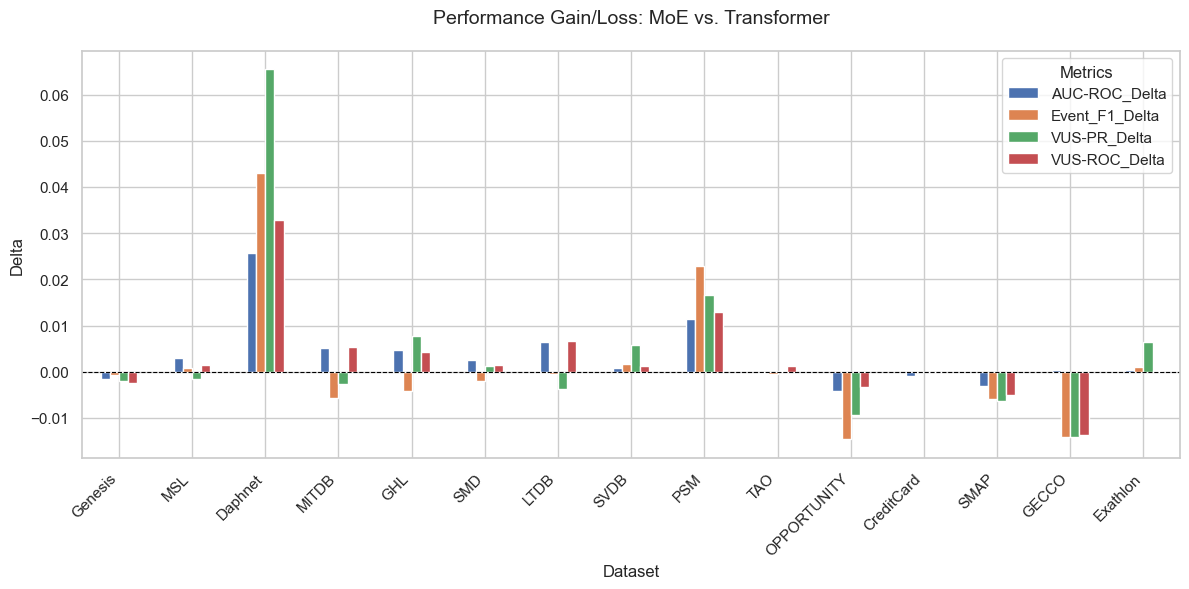

<Figure size 1200x500 with 0 Axes>

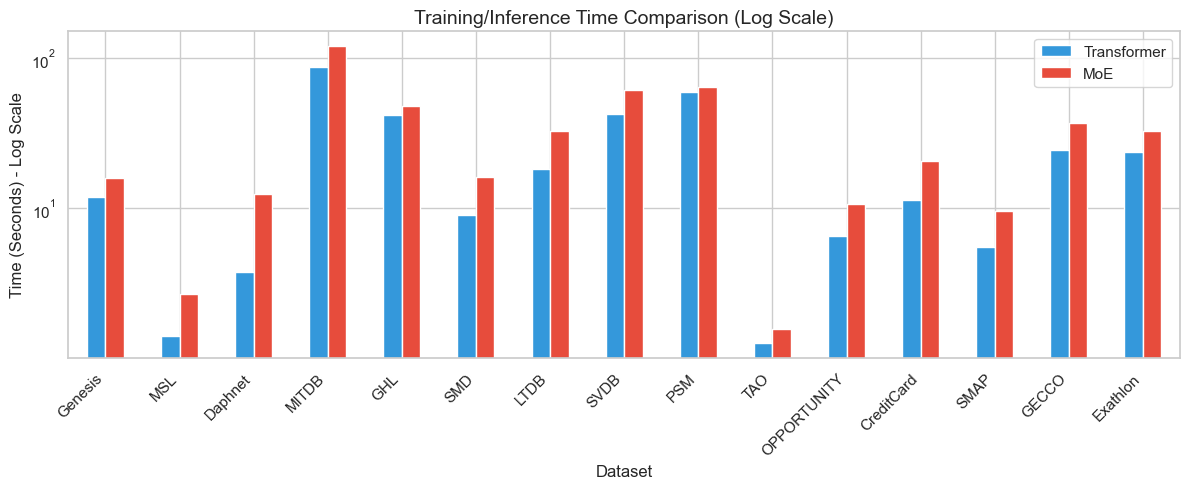

In [17]:
# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 10})

# 1. Performance Deltas across Datasets
# Shows exactly where MoE improves performance vs where it might degrade it
fig, ax1 = plt.subplots(figsize=(12, 6))

# We'll plot AUC-ROC Delta and Event-F1 Delta
comparison_table[['AUC-ROC_Delta', 'Event_F1_Delta', 'VUS-PR_Delta', 'VUS-ROC_Delta']].plot(kind='bar', ax=ax1)
ax1.set_title('Performance Gain/Loss: MoE vs. Transformer', fontsize=14, pad=20)
ax1.set_ylabel('Delta')
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metrics')
plt.tight_layout()
plt.savefig('performance_deltas.png')

# 3. Direct Runtime Comparison (Log Scale)
# Useful if some datasets take seconds and others take hours
plt.figure(figsize=(12, 5))
comparison_table[['Trans_Time', 'MoE_Time']].plot(kind='bar', logy=True, figsize=(12,5), color=['#3498db', '#e74c3c'])
plt.title('Training/Inference Time Comparison (Log Scale)', fontsize=14)
plt.ylabel('Time (Seconds) - Log Scale')
plt.xticks(rotation=45, ha='right')
plt.legend(['Transformer', 'MoE'])
plt.tight_layout()
plt.savefig('time_comparison.png')

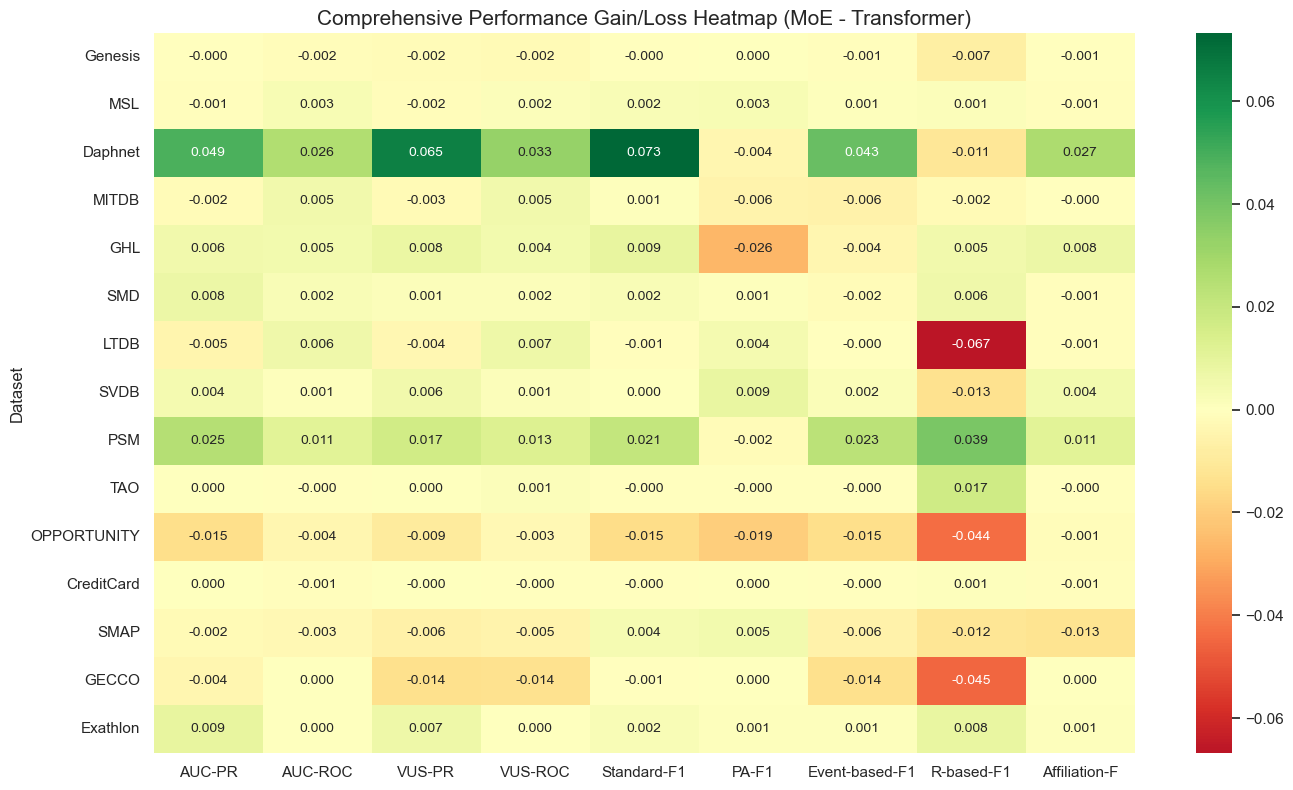

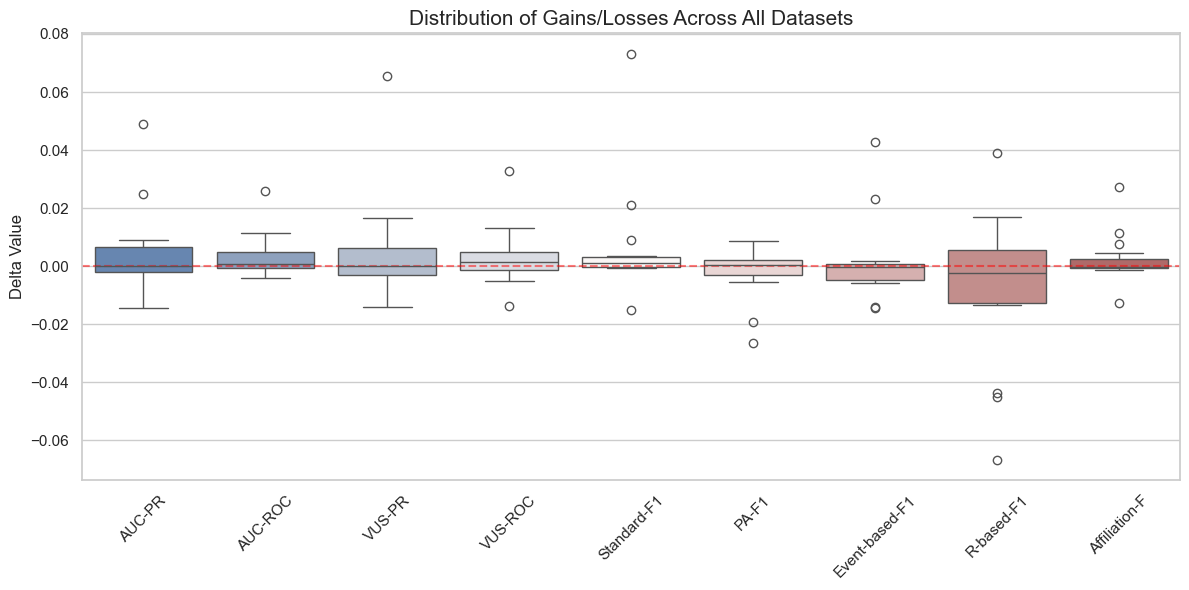

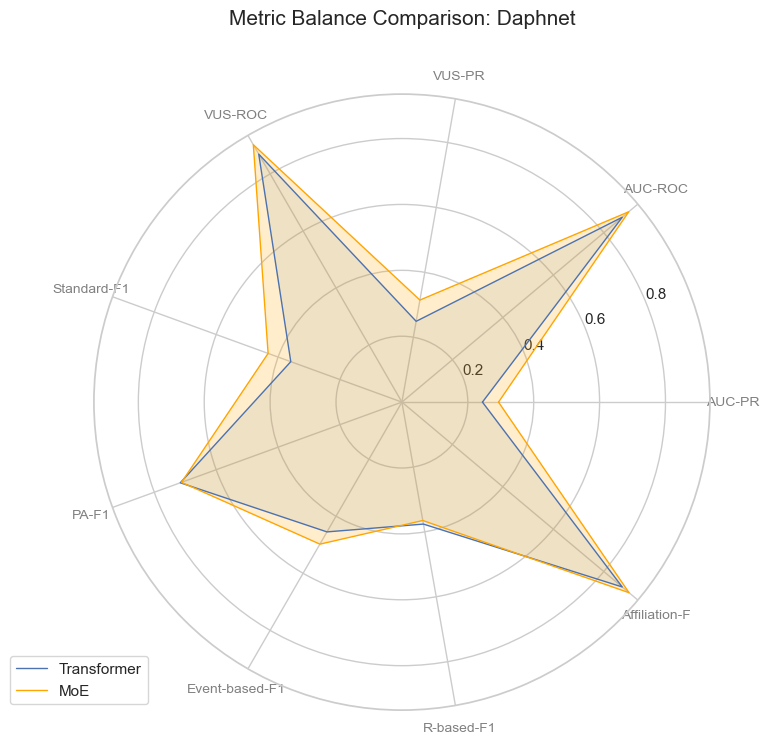

In [10]:
from math import pi

# 1. Expanded Summary Data (Calculating Deltas for ALL metrics)
all_metrics = ['AUC-PR', 'AUC-ROC', 'VUS-PR', 'VUS-ROC', 'Standard-F1', 'PA-F1', 
               'Event-based-F1', 'R-based-F1', 'Affiliation-F']
delta_data = []

for ds in datasets:
    df_trans = transformer_groups.get(ds)
    df_moe = MOE_groups.get(ds)
    if df_trans is None or df_moe is None: continue
    
    # Calculate means
    m_t = df_trans[all_metrics].mean()
    m_m = df_moe[all_metrics].mean()
    
    # Calculate Deltas
    deltas = (m_m - m_t).to_dict()
    deltas['Dataset'] = ds
    delta_data.append(deltas)

df_deltas = pd.DataFrame(delta_data).set_index('Dataset')

# --- PLOT 1: ALL-METRIC DELTA HEATMAP ---
plt.figure(figsize=(14, 8))
sns.heatmap(df_deltas, annot=True, cmap='RdYlGn', center=0, fmt=".3f")
plt.title('Comprehensive Performance Gain/Loss Heatmap (MoE - Transformer)', fontsize=15)
plt.tight_layout()
plt.savefig('all_metrics_heatmap.png')

# --- PLOT 2: METRIC RELIABILITY BOXPLOT ---
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_deltas, palette="vlag")
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.title('Distribution of Gains/Losses Across All Datasets', fontsize=15)
plt.ylabel('Delta Value')
plt.tight_layout()
plt.savefig('metric_distribution_boxplot.png')

# --- PLOT 3: RADAR CHART (Daphnet vs. Transformer) ---
def make_radar(dataset_name):
    # Prepare data
    labels = all_metrics
    num_vars = len(labels)
    
    # Get values for both models
    t_vals = transformer_groups[dataset_name][all_metrics].mean().values.tolist()
    m_vals = MOE_groups[dataset_name][all_metrics].mean().values.tolist()
    
    # Close the circle
    t_vals += t_vals[:1]
    m_vals += m_vals[:1]
    angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    plt.xticks(angles[:-1], labels, color='grey', size=10)
    
    # Plot Transformer
    ax.plot(angles, t_vals, linewidth=1, linestyle='solid', label="Transformer")
    ax.fill(angles, t_vals, 'b', alpha=0.1)
    
    # Plot MoE
    ax.plot(angles, m_vals, linewidth=1, linestyle='solid', label="MoE", color='orange')
    ax.fill(angles, m_vals, 'orange', alpha=0.2)
    
    plt.title(f'Metric Balance Comparison: {dataset_name}', size=15, y=1.1)
    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
    plt.savefig(f'radar_comparison_{dataset_name}.png')

make_radar('Daphnet')

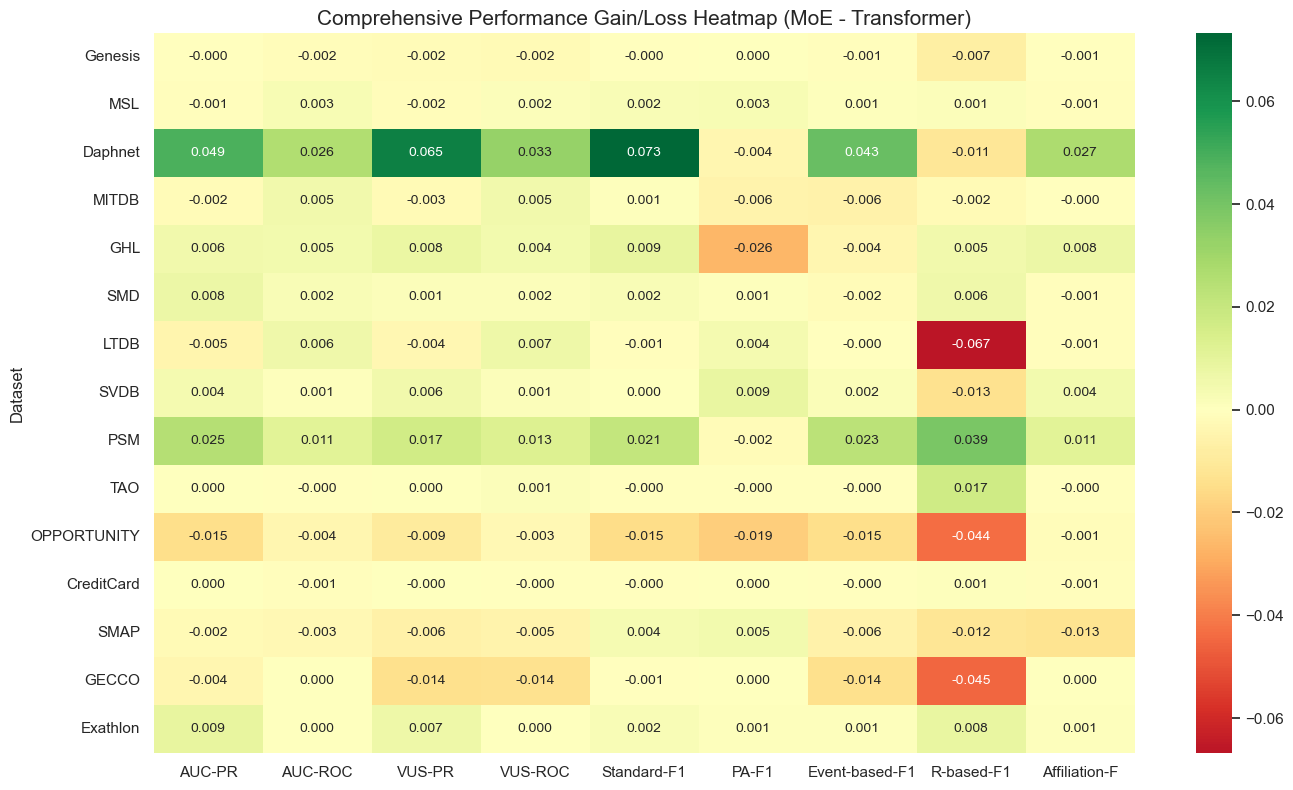

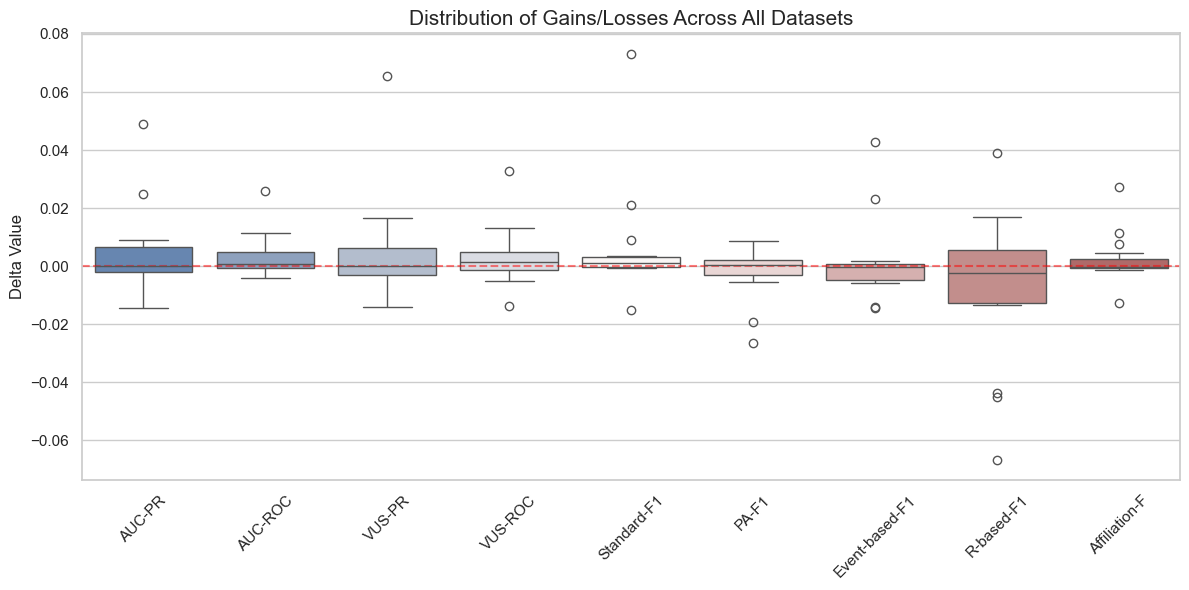

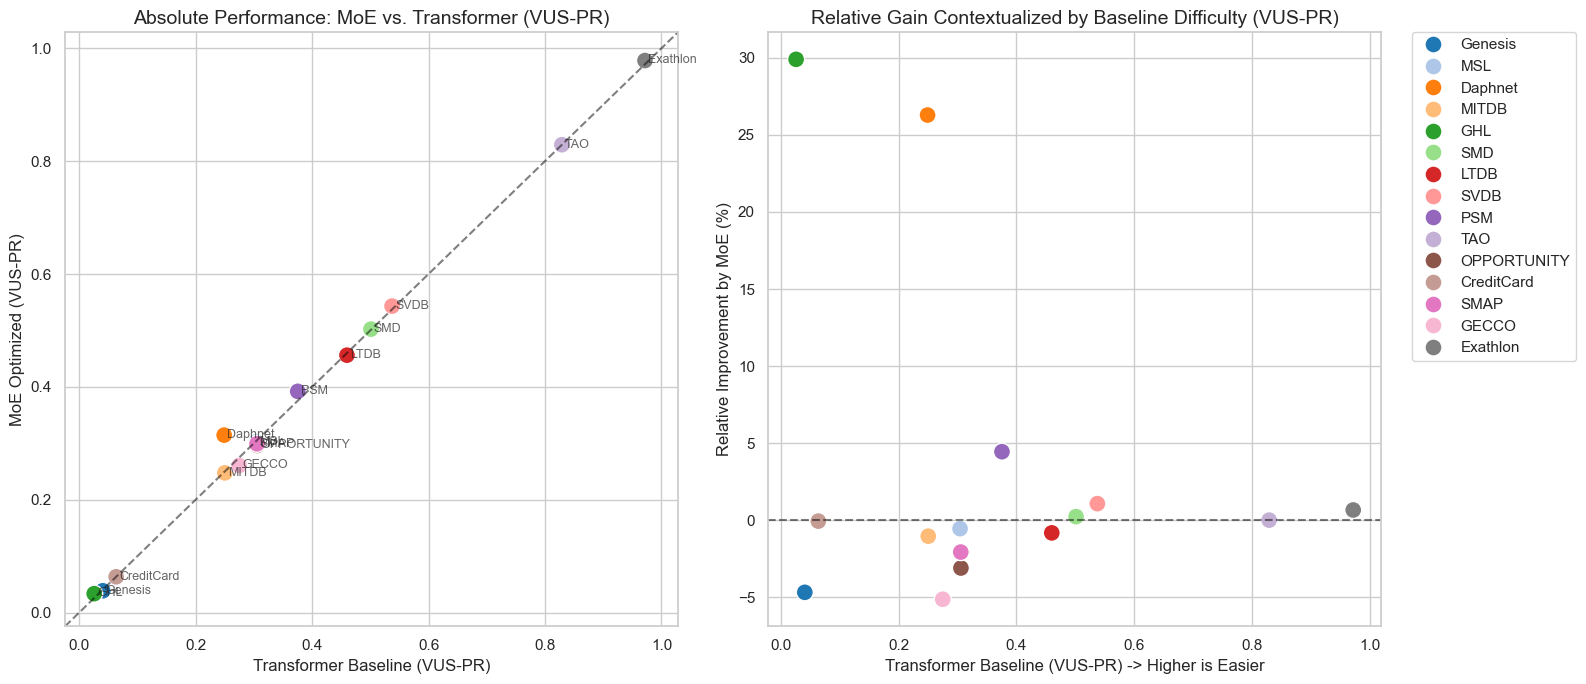

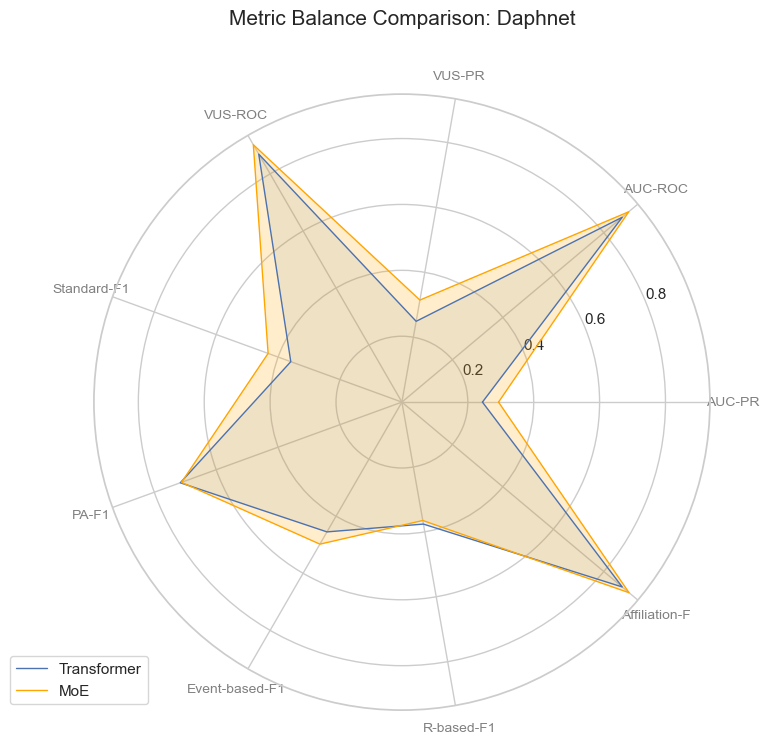

In [26]:
# 1. Expanded Summary Data (Calculating Deltas for ALL metrics)
all_metrics = ['AUC-PR', 'AUC-ROC', 'VUS-PR', 'VUS-ROC', 'Standard-F1', 'PA-F1', 
               'Event-based-F1', 'R-based-F1', 'Affiliation-F']
delta_data = []
scatter_data = [] # NEW: Storing absolute scores for the scatter plots

# Set the primary metric you want to evaluate in the scatter plots
target_metric = 'VUS-PR' 

for ds in datasets:
    df_trans = transformer_groups.get(ds)
    df_moe = MOE_groups.get(ds)
    if df_trans is None or df_moe is None: continue
    
    # Calculate means
    m_t = df_trans[all_metrics].mean()
    m_m = df_moe[all_metrics].mean()
    
    # Calculate Deltas for the Heatmap/Boxplot
    deltas = (m_m - m_t).to_dict()
    deltas['Dataset'] = ds
    delta_data.append(deltas)

    # NEW: Extract specific baseline and MoE scores for the Scatter Plots
    t_val = m_t[target_metric]
    m_val = m_m[target_metric]
    delta_val = m_val - t_val
    imp_pct = (delta_val / t_val * 100) if t_val != 0 else 0
    
    scatter_data.append({
        'Dataset': ds,
        'Transformer_Score': t_val,
        'MoE_Score': m_val,
        'Improvement_Percent': imp_pct
    })

df_deltas = pd.DataFrame(delta_data).set_index('Dataset')
df_scatter = pd.DataFrame(scatter_data) # NEW: Scatter dataframe

# --- PLOT 1: ALL-METRIC DELTA HEATMAP ---
plt.figure(figsize=(14, 8))
sns.heatmap(df_deltas, annot=True, cmap='RdYlGn', center=0, fmt=".3f")
plt.title('Comprehensive Performance Gain/Loss Heatmap (MoE - Transformer)', fontsize=15)
plt.tight_layout()
plt.savefig('all_metrics_heatmap.png')

# --- PLOT 2: METRIC RELIABILITY BOXPLOT ---
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_deltas, palette="vlag")
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.title('Distribution of Gains/Losses Across All Datasets', fontsize=15)
plt.ylabel('Delta Value')
plt.tight_layout()
plt.savefig('metric_distribution_boxplot.png')

# --- PLOT 3: CONTEXTUAL PERFORMANCE SCATTER PLOTS (NEW) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
sns.set_theme(style="whitegrid")

# Left: Absolute Comparison (y = x)
sns.scatterplot(
    data=df_scatter, x='Transformer_Score', y='MoE_Score', 
    hue='Dataset', s=150, palette='tab20', ax=ax1, legend=False
)
# Dynamic limits based on your actual data ranges
min_val = min(df_scatter['Transformer_Score'].min(), df_scatter['MoE_Score'].min()) - 0.05
max_val = max(df_scatter['Transformer_Score'].max(), df_scatter['MoE_Score'].max()) + 0.05
ax1.plot([min_val, max_val], [min_val, max_val], ls='--', c='black', alpha=0.5)
ax1.set_xlim([min_val, max_val])
ax1.set_ylim([min_val, max_val])
ax1.set_title(f'Absolute Performance: MoE vs. Transformer ({target_metric})', fontsize=14)
ax1.set_xlabel(f'Transformer Baseline ({target_metric})', fontsize=12)
ax1.set_ylabel(f'MoE Optimized ({target_metric})', fontsize=12)

# Annotate points
for i in range(df_scatter.shape[0]):
    ax1.text(df_scatter['Transformer_Score'][i] + 0.005, df_scatter['MoE_Score'][i] - 0.005, 
             df_scatter['Dataset'][i], fontsize=9, alpha=0.7)

# Right: Relative Gain Contextualized by Dataset Difficulty
sns.scatterplot(
    data=df_scatter, x='Transformer_Score', y='Improvement_Percent', 
    hue='Dataset', s=150, palette='tab20', ax=ax2
)
ax2.axhline(0, ls='--', c='black', alpha=0.5)
ax2.set_title(f'Relative Gain Contextualized by Baseline Difficulty ({target_metric})', fontsize=14)
ax2.set_xlabel(f'Transformer Baseline ({target_metric}) -> Higher is Easier', fontsize=12)
ax2.set_ylabel('Relative Improvement by MoE (%)', fontsize=12)
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.savefig(f'contextual_performance_scatter_{target_metric}.png', dpi=300)

# --- PLOT 4: RADAR CHART (Daphnet vs. Transformer) ---
def make_radar(dataset_name):
    # Prepare data
    labels = all_metrics
    num_vars = len(labels)
    
    # Get values for both models
    t_vals = transformer_groups[dataset_name][all_metrics].mean().values.tolist()
    m_vals = MOE_groups[dataset_name][all_metrics].mean().values.tolist()
    
    # Close the circle
    t_vals += t_vals[:1]
    m_vals += m_vals[:1]
    angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    plt.xticks(angles[:-1], labels, color='grey', size=10)
    
    # Plot Transformer
    ax.plot(angles, t_vals, linewidth=1, linestyle='solid', label="Transformer")
    ax.fill(angles, t_vals, 'b', alpha=0.1)
    
    # Plot MoE
    ax.plot(angles, m_vals, linewidth=1, linestyle='solid', label="MoE", color='orange')
    ax.fill(angles, m_vals, 'orange', alpha=0.2)
    
    plt.title(f'Metric Balance Comparison: {dataset_name}', size=15, y=1.1)
    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
    plt.savefig(f'radar_comparison_{dataset_name}.png')

make_radar('Daphnet')

In [24]:
MOE_groups.get(ds)

,file,Time,AUC-PR,AUC-ROC,VUS-PR,VUS-ROC,Standard-F1,PA-F1,Event-based-F1,R-based-F1,Affiliation-F,source
155,174_Exathlon_id_1_Facility_tr_10766_1st_12590.csv,28.732563,0.882415,0.994766,0.895256,0.994852,0.971679,0.983449,0.982661,0.850349,0.983964,Exathlon
156,175_Exathlon_id_2_Facility_tr_10684_1st_10784.csv,41.841333,0.998057,0.999831,0.997486,0.999835,0.979950,1.000000,1.000000,0.945794,0.999739,Exathlon
157,176_Exathlon_id_3_Facility_tr_10766_1st_12590.csv,33.622360,0.988451,0.999241,0.997595,0.999810,0.980099,1.000000,1.000000,0.982898,0.999501,Exathlon
158,177_Exathlon_id_4_Facility_tr_11665_1st_13484.csv,29.435760,0.989294,0.999286,0.988840,0.999366,0.959789,1.000000,1.000000,0.822670,0.998345,Exathlon
159,179_Exathlon_id_6_Facility_tr_11665_1st_13484.csv,26.149215,0.955674,0.998677,0.958182,0.998797,0.965900,1.000000,1.000000,0.807303,0.990415,Exathlon
160,180_Exathlon_id_7_Facility_tr_10766_1st_12590.csv,42.892294,0.986454,0.999165,0.997063,0.999786,0.979154,1.000000,1.000000,0.911143,0.999437,Exathlon
161,181_Exathlon_id_8_Facility_tr_11663_1st_13482.csv,38.088504,0.968185,0.997723,0.966312,0.997787,0.948647,1.000000,1.000000,0.632504,0.998618,Exathlon
162,182_Exathlon_id_9_Facility_tr_10766_1st_12590.csv,34.197653,0.987822,0.999215,0.997462,0.999804,0.979340,1.000000,1.000000,0.982823,0.999485,Exathlon
163,183_Exathlon_id_10_Facility_tr_11665_1st_13484...,20.772892,0.988487,0.999246,0.986440,0.999258,0.952566,1.000000,1.000000,0.816859,0.998200,Exathlon
164,184_Exathlon_id_11_Facility_tr_11665_1st_13484...,30.392644,0.989531,0.999310,0.987715,0.999329,0.959789,1.000000,1.000000,0.816237,0.998275,Exathlon


In [ ]:
# # Now you access it like this:
# transformer_genesis_results = transformer_groups['Genesis']
# transformer_msl_results = transformer_groups['MSL']
# transformer_daphnet_results = transformer_groups['Daphnet']
# transformer_MITDB_results = transformer_groups['MITDB']
# transformer_GHL_results = transformer_groups['GHL']
# transformer_SMD_results = transformer_groups['SMD']
# transformer_LTDB_results = transformer_groups['LTDB']
# transformer_SVDB_results = transformer_groups['SVDB']
# transformer_PSM_results = transformer_groups['PSM']
# transformer_TAO_results = transformer_groups['TAO']
# transformer_OPPORTUNITY_results = transformer_groups['OPPORTUNITY']
# transformer_CreditCard_results = transformer_groups['CreditCard']
# transformer_CATSv2_results = transformer_groups['CATSv']
# transformer_SMAP_results = transformer_groups['SMAP']
# transformer_GECCO_results = transformer_groups['GECCO']
# transformer_Exathlon_results = transformer_groups['Exathlon']


# # Now you access it like this:
# MOE_genesis_results = MOE_groups['Genesis']
# MOE_msl_results = MOE_groups['MSL']
# MOE_daphnet_results = MOE_groups['Daphnet']
# MOE_MITDB_results = MOE_groups['MITDB']
# MOE_GHL_results = MOE_groups['GHL']
# MOE_SMD_results = MOE_groups['SMD']
# MOE_LTDB_results = MOE_groups['LTDB']
# MOE_SVDB_results = MOE_groups['SVDB']
# MOE_PSM_results = MOE_groups['PSM']
# MOE_TAO_results = MOE_groups['TAO']
# MOE_OPPORTUNITY_results = MOE_groups['OPPORTUNITY']
# MOE_CreditCard_results = MOE_groups['CreditCard']
# MOE_CATSv2_results = MOE_groups['CATSv']
# MOE_SMAP_results = MOE_groups['SMAP']
# MOE_GECCO_results = MOE_groups['GECCO']
# MOE_Exathlon_results = MOE_groups['Exathlon']